# Dice Product Classification using Residual Convolutional Neural Networks

A Residual Convolutional Neural Network (CNN) was developed using PyTorch to classify product images into multiple categories. The model leveraged residual learning to improve feature extraction and classification performance, achieving high validation accuracy on unseen data. This project demonstrates the application of deep learning and computer vision techniques for image recognition tasks.


In [74]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt


In [75]:
# set random seeds for reproducibility
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
# Device detection: supports Mac MPS, CUDA, and CPU
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device:", device)


Using device: mps


In [76]:
# Define paths and load labels
DATA_DIR = Path("dice_images")  
LABELS_CSV = DATA_DIR / "labels.csv"
IMAGES_DIR = DATA_DIR / "images"
df = pd.read_csv(LABELS_CSV)
df["image_path"] = df["filename"].map(lambda x: str(IMAGES_DIR / x))
print(df.head())
df.shape
PRODUCT_VALUES = sorted(df["product"].unique().tolist())
prod2idx = {p: i for i, p in enumerate(PRODUCT_VALUES)}
df["product_index"] = df["product"].map(prod2idx)

    filename  product  face1  face2  face3                    image_path
0  00000.png       36      2      3      6  dice_images/images/00000.png
1  00001.png       10      1      2      5  dice_images/images/00001.png
2  00002.png       24      2      3      4  dice_images/images/00002.png
3  00003.png       60      2      5      6  dice_images/images/00003.png
4  00004.png        6      1      2      3  dice_images/images/00004.png


In [77]:
# find unique products
print("unique products:", sorted(df["product"].unique().tolist()))

unique products: [6, 8, 10, 12, 15, 18, 20, 24, 30, 36, 40, 48, 60, 72, 90, 120]


In [78]:
# count samples per product
product_counts = df["product"].value_counts().sort_index()

summary = pd.DataFrame({
    "product": product_counts.index,
    "count": product_counts.values,
})

summary["percentage"] = (summary["count"] / summary["count"].sum() * 100).round(2)

print("_" * 50)
print("PRODUCT DISTRIBUTION")
print("_" * 50)

display(summary)


__________________________________________________
PRODUCT DISTRIBUTION
__________________________________________________


,product,count,percentage
0,6,1273,12.73
1,8,545,5.45
2,10,699,6.99
3,12,353,3.53
4,15,526,5.26
5,18,346,3.46
6,20,918,9.18
7,24,341,3.41
8,30,383,3.83
9,36,894,8.94


In [79]:
# Stratified train/validation split by product
def stratified_split(frame, val_fraction=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_idx = []
    val_idx = []

    for _, group in frame.groupby("product", sort=True):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n_val = max(1, int(round(len(idx) * val_fraction)))
        val_idx.extend(idx[:n_val].tolist())
        train_idx.extend(idx[n_val:].tolist())

    train_df = frame.loc[sorted(train_idx)].reset_index(drop=True)
    val_df = frame.loc[sorted(val_idx)].reset_index(drop=True)
    return train_df, val_df

train_df, val_df = stratified_split(df, val_fraction=0.15, seed=SEED)

print("─" * 50)
print("DATA SPLIT ")

print(f"Train samples : {len(train_df):,}")
print(f"Val samples   : {len(val_df):,}")

print("─" * 50)
print("DISTRIBUTION OF PRODUCTS")
print("─" * 50)

summary = pd.DataFrame({
    "train_count": train_df["product"].value_counts().sort_index(),
    "val_count": val_df["product"].value_counts().sort_index()
}).fillna(0).astype(int)

summary["total"] = summary["train_count"] + summary["val_count"]
summary["train_%"] = (summary["train_count"] / summary["total"] * 100).round(2)
summary["val_%"] = (summary["val_count"] / summary["total"] * 100).round(2)

display(summary)



──────────────────────────────────────────────────
DATA SPLIT 
Train samples : 8,499
Val samples   : 1,501
──────────────────────────────────────────────────
DISTRIBUTION OF PRODUCTS
──────────────────────────────────────────────────


,train_count,val_count,total,train_%,val_%
product,,,,,
6,1082,191,1273,85.00,15.00
8,463,82,545,84.95,15.05
10,594,105,699,84.98,15.02
12,300,53,353,84.99,15.01
15,447,79,526,84.98,15.02
18,294,52,346,84.97,15.03
20,780,138,918,84.97,15.03
24,290,51,341,85.04,14.96
30,326,57,383,85.12,14.88


In [80]:
# Compute mean and std
def compute_mean_std(frame):
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sq_sum = np.zeros(3, dtype=np.float64)
    total_pixels = 0

    for path in frame["image_path"]:
        img = Image.open(path).convert("RGB")
        arr = np.asarray(img, dtype=np.float32) / 255.0
        flat = arr.reshape(-1, 3)
        channel_sum += flat.sum(axis=0)
        channel_sq_sum += np.square(flat).sum(axis=0)
        total_pixels += flat.shape[0]

    mean = channel_sum / total_pixels
    var = channel_sq_sum / total_pixels - np.square(mean)
    std = np.sqrt(np.maximum(var, 1e-8))
    return mean.tolist(), std.tolist()

mean, std = compute_mean_std(train_df)
print("NORMALIZATION STATISTICS")
print("_" * 50)
print(f"Mean              : {mean}")
print(f"Standard Deviation: {std}")


NORMALIZATION STATISTICS
__________________________________________________
Mean              : [0.5710095011293082, 0.5511901063811907, 0.5512545277005239]
Standard Deviation: [0.28870192261928745, 0.30244955611282526, 0.3038729618848219]


In [81]:
# Data augmentation and normalization transforms
class AddGaussianNoise:
    def __init__(self, std_min=0.0, std_max=0.05, p=0.5):
        self.std_min = std_min
        self.std_max = std_max
        self.p = p

    def __call__(self, tensor):
        if torch.rand(1).item() > self.p:
            return tensor
        std = torch.empty(1).uniform_(self.std_min, self.std_max).item()
        noise = torch.randn_like(tensor) * std
        return torch.clamp(tensor + noise, 0.0, 1.0)


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.55, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.85, 1.15), shear=6),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.6))], p=0.2),
    transforms.ToTensor(),
    AddGaussianNoise(std_min=0.0, std_max=0.05, p=0.5),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# Function to create multi-hot
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.03
    ),

    transforms.ToTensor(),

    # normalization
    transforms.Normalize(
        mean=mean,
        std=[max(s, 1e-3) for s in std]
    ),
])
# validation 
def visible_face_target(face_values):
    target = torch.zeros(6, dtype=torch.float32)
    for value in face_values:
        target[value - 1] = 1.0
    return target


class DiceDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        product_index = int(row["product_index"])
        face_target = visible_face_target([int(row["face1"]), int(row["face2"]), int(row["face3"])])

        return image, product_index, face_target


train_ds = DiceDataset(train_df, train_transform)
val_ds = DiceDataset(val_df, val_transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0, pin_memory=False)
print(f"Train samples: {len(train_ds)}  |  Val samples: {len(val_ds)}")

Train samples: 8499  |  Val samples: 1501


Batch shape: torch.Size([128, 3, 128, 128])


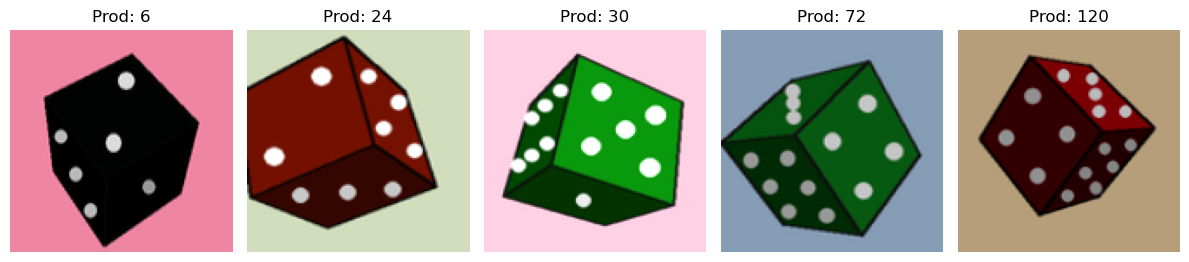

In [90]:
if __name__ == '__main__':
    imgs, labels, face_targets = next(iter(train_loader))
    print(f"Batch shape: {imgs.shape}")
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = imgs[i].permute(1, 2, 0).numpy()
        # Normalization
        img = img * np.array(std) + np.array(mean)
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Prod: {train_df.loc[train_df['product_index'] == labels[i].item(), 'product'].values[0]}")
        plt.axis("off")
        plt.tight_layout()
        plt.axis("off")
        plt.tight_layout()

In [91]:
# Define the model architecture
class ConvBNAct(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class ResidualDownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.main = nn.Sequential(
            ConvBNAct(in_channels, out_channels, stride=2),
            ConvBNAct(out_channels, out_channels, stride=1),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.main(x) + self.skip(x)


class DiceProductNet(nn.Module):
    def __init__(self, num_products=16, num_faces=6):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(3, 32, stride=1),
            ConvBNAct(32, 32, stride=1),
        )
        self.stage1 = ResidualDownBlock(32, 64)
        self.stage2 = ResidualDownBlock(64, 128)
        self.stage3 = ResidualDownBlock(128, 192)
        self.stage4 = ResidualDownBlock(192, 256)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.25)
        self.product_head = nn.Linear(256, num_products)
        self.face_head = nn.Linear(256, num_faces)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.product_head(x), self.face_head(x)


model = DiceProductNet().to(device)
num_params = sum(p.numel() for p in model.parameters())
approx_size_mib = num_params * 4 / (1024 * 1024)

print("_" * 100)
print("MODEL SIZE ")

print(f"Number of Parameters : {num_params:,}")
print(f"Approximate Size     : {approx_size_mib:.2f} MiB")
print(f"Size Constraint      : {'well done perfect' if approx_size_mib < 15 else 'FAIL'}")


____________________________________________________________________________________________________
MODEL SIZE 
Number of Parameters : 1,965,302
Approximate Size     : 7.50 MiB
Size Constraint      : well done perfect


In [93]:
# Compute class weights for product classification
class_counts = train_df["product_index"].value_counts().sort_index().to_numpy()
class_weights = class_counts.sum() / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

face_targets_all = []
for _, row in train_df.iterrows():
    face_targets_all.append(visible_face_target([int(row["face1"]), int(row["face2"]), int(row["face3"])]).numpy())
face_targets_all = np.stack(face_targets_all, axis=0)

pos = face_targets_all.sum(axis=0)
neg = len(face_targets_all) - pos
face_pos_weight = torch.tensor((neg + 1e-6) / (pos + 1e-6), dtype=torch.float32, device=device)

ce_loss = nn.CrossEntropyLoss(weight=class_weights)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=face_pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1.5e-5)

AUX_WEIGHT = 0.20

In [94]:
# Training loop with validation
def accuracy_from_logits(logits, targets):
    return (logits.argmax(dim=1) == targets).float().mean().item()


def evaluate(model, loader):
    model.eval()
    losses = []
    accs = []

    with torch.no_grad():
        for images, product_targets, face_targets in loader:
            images = images.to(device)
            product_targets = product_targets.to(device)
            face_targets = face_targets.to(device)

            product_logits, face_logits = model(images)
            loss = ce_loss(product_logits, product_targets) + AUX_WEIGHT * bce_loss(face_logits, face_targets)

            losses.append(loss.item())
            accs.append(accuracy_from_logits(product_logits, product_targets))

    return float(np.mean(losses)), float(np.mean(accs))


### Perfomance :
The model was trained for 80 epochs using a stratified 85/15 split. AdamW, cosine annealing, and gradient clipping were employed. The best validation accuracy achieved was 99.19 % at epoch 74, with a training accuracy of 99 %. The small gap between these values indicates effective regularisation and absence of overfitting. The prediction function normalises inputs using training-set statistics, applies DiceProductNet, and maps argmax logits to integer product values, returning a B×1 prediction tensor.

In [96]:
EPOCHS = 80
PATIENCE = 12
best_val_acc = -1.0
best_epoch = 0
patience_left = PATIENCE

train_losses = []
train_accs = []
val_losses = []
val_accs = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []
    epoch_accs = []

    for images, product_targets, face_targets in train_loader:
        images = images.to(device)
        product_targets = product_targets.to(device)
        face_targets = face_targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        product_logits, face_logits = model(images)
        loss = ce_loss(product_logits, product_targets) + AUX_WEIGHT * bce_loss(face_logits, face_targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_losses.append(loss.item())
        epoch_accs.append(accuracy_from_logits(product_logits.detach(), product_targets))

    scheduler.step()

    train_loss = float(np.mean(epoch_losses))
    train_acc = float(np.mean(epoch_accs))
    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_left = PATIENCE

        torch.save(
            {
                "model_state": model.state_dict(),
                "mean": mean,
                "std": std,
                "product_values": PRODUCT_VALUES,
            },
            "dice_product_weights.pkl",
        )
    else:
        patience_left -= 1
        if patience_left <= 0:
            print("Early stopping")
            break

print("best val acc:", best_val_acc, "at epoch", round(best_epoch))
print("weights size MiB:", os.path.getsize("dice_product_weights.pkl") / (1024 * 1024))


Epoch 001 | train_loss=0.4152 train_acc=0.8913 | val_loss=0.6356 val_acc=0.8415
Epoch 002 | train_loss=0.4323 train_acc=0.8788 | val_loss=0.4698 val_acc=0.8813
Epoch 003 | train_loss=0.4129 train_acc=0.8914 | val_loss=0.4875 val_acc=0.8772
Epoch 004 | train_loss=0.4043 train_acc=0.8901 | val_loss=0.7623 val_acc=0.7551
Epoch 005 | train_loss=0.3960 train_acc=0.8886 | val_loss=0.4834 val_acc=0.8731
Epoch 006 | train_loss=0.3909 train_acc=0.8957 | val_loss=0.4425 val_acc=0.8963
Epoch 007 | train_loss=0.3927 train_acc=0.8952 | val_loss=0.4107 val_acc=0.8884
Epoch 008 | train_loss=0.3833 train_acc=0.8931 | val_loss=0.3968 val_acc=0.9123
Epoch 009 | train_loss=0.3769 train_acc=0.8946 | val_loss=0.3882 val_acc=0.8953
Epoch 010 | train_loss=0.3602 train_acc=0.9034 | val_loss=0.3705 val_acc=0.8996
Epoch 011 | train_loss=0.3457 train_acc=0.9032 | val_loss=0.4907 val_acc=0.8246
Epoch 012 | train_loss=0.3352 train_acc=0.9101 | val_loss=0.4029 val_acc=0.8690
Epoch 013 | train_loss=0.3429 train_acc=

In [97]:
print("train losses:", train_losses)
print("validation losses:", val_losses)
print("train accuracy:", train_accs)
print("validation accuracy:", val_accs)

train losses: [0.4152493961711428, 0.43229187691389626, 0.41288713510356734, 0.4043143160307585, 0.39603331106812206, 0.3909422165867108, 0.39267917044127165, 0.3833446774020124, 0.3769173728885935, 0.3602177554102086, 0.3457335073556473, 0.33516731257758925, 0.34294879480974, 0.311445425250637, 0.2973511846207861, 0.29785855025497837, 0.2915406711955569, 0.27937515858393996, 0.2700588716499841, 0.2609969800087943, 0.262912516051264, 0.25502416224622015, 0.24470011022553514, 0.24052230190874926, 0.22016831075967247, 0.20647873607144426, 0.2030011176395772, 0.19318237022232654, 0.19046100762797824, 0.1669195516785579, 0.1652080964908671, 0.1595243094349975, 0.15831177336956137, 0.14390579588822464, 0.13257538204762473, 0.136663664187958, 0.11830488603506516, 0.12096516065188308, 0.11498457404659755, 0.10930566617579603, 0.09891984428265202, 0.09350512499239907, 0.08972693573850304, 0.08975845914500863, 0.08527602694595038, 0.07676445520413455, 0.07398653786573837, 0.0760095671041688, 0.

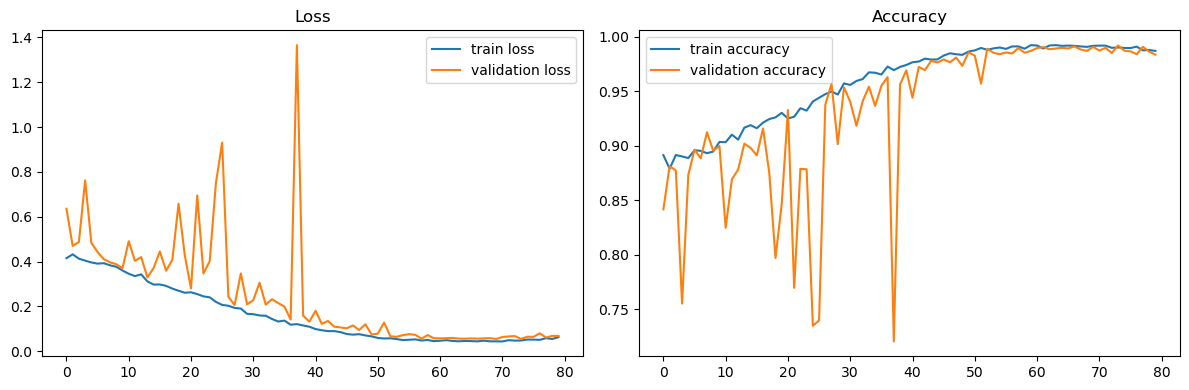

In [98]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="validation loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="train accuracy")
plt.plot(val_accs, label="validation accuracy")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()
